Import required libraries

In [34]:
# Install required libraries (if not already installed)
!pip install pandas numpy scikit-learn imbalanced-learn scipy xgboost matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score

from imblearn.over_sampling import RandomOverSampler

from scipy.stats import chi2_contingency, ttest_ind, f_oneway, kruskal

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
#from google.colab import files
#uploaded = files.upload()

In [23]:
print("\n Loading dataset...")
# Load dataset

file_path = "/content/sample_data/Data_Training.xlsx"

df = pd.read_excel(file_path)

print(" Data Loaded Successfully")
print("\nShape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nSample Data:\n", df.head())
print("\nData Info:")
print(df.info())
print("\nSummary Statistics:\n", df.describe(include='all'))

print("Dataset loaded successfully!")



 Loading dataset...
 Data Loaded Successfully

Shape: (109314, 13)

Columns:
 ['Education Level', 'Emp_Level', 'Birth Year', 'Zip', 'Demographic_Category', 'Product_Cate', 'Loan_Amt', 'LTV_Perc', 'Housing_Category', 'Net_Sal', 'Region_Level', 'Existing_Liabilities', 'Loan_Given']

Sample Data:
    Education Level Emp_Level  Birth Year     Zip Demographic_Category  \
0              1.0        AG        1978  502109                    M   
1              3.0        SA        1995  503001                    M   
2              4.0        NR        2001  500089                    M   
3              3.0        SA        1981  501140                    M   
4              1.0        SA        1984  509333                    M   

   Product_Cate  Loan_Amt  LTV_Perc Housing_Category  Net_Sal  Region_Level  \
0             2     59400     69.77            Owner    40000           7.0   
1             3    153939     85.00            Owner    26000           5.0   
2             1     78058  

In [24]:
print("No of rows missing Loan_Given values", df["Loan_Given"].isna().sum())

df = df.dropna(subset=["Loan_Given"])
df = df[df["Loan_Given"].astype(str).str.strip() != ""]

print("deleted rows")
print("", df["Loan_Given"].isna().sum())
print("after deleting rows dataframe shape:", df.shape)

No of rows missing Loan_Given values 12
deleted rows
 0
after deleting rows dataframe shape: (109302, 13)


In [25]:
# Separate X and y
target_col = "Loan_Given"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Identified Features and Target")
print("X shape:", X.shape)
print("y shape:", y.shape)

assert target_col not in X.columns


Identified Features and Target
X shape: (109302, 12)
y shape: (109302,)


In [26]:
current_year = datetime.datetime.now().year

X["Age"] = current_year - X["Birth Year"]

# Drop columns
X = X.drop(columns=["Birth Year", "Region_Level", "Zip"])

print("Feature engineering done")
print("Columns:", X.columns.tolist())

Feature engineering done
Columns: ['Education Level', 'Emp_Level', 'Demographic_Category', 'Product_Cate', 'Loan_Amt', 'LTV_Perc', 'Housing_Category', 'Net_Sal', 'Existing_Liabilities', 'Age']


In [27]:
def merge_rare(series, threshold=0.02):
    freq = series.value_counts(normalize=True)
    rare = freq[freq < threshold].index
    return series.replace(rare, "Other")

for col in X.select_dtypes(include="object").columns:
    X[col] = merge_rare(X[col])

print("Rare categories merged")

Rare categories merged


In [28]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Emp_Level', 'Demographic_Category', 'Housing_Category', 'Existing_Liabilities']
Numerical: ['Education Level', 'Product_Cate', 'Loan_Amt', 'LTV_Perc', 'Net_Sal', 'Age']


Feature Selection

In [29]:
print("\n Hypothesis Testing\n")

# 1. Chi-square
print(" Chi-square: Emp_Level vs Loan_Given")
cont = pd.crosstab(df["Emp_Level"], df["Loan_Given"])
chi2, p, _, _ = chi2_contingency(cont)
print("p-value:", p)

# 2. T-test
print("\n T-test: Loan_Amt vs Loan_Given")
g1 = df[df["Loan_Given"] == 1]["Loan_Amt"]
g0 = df[df["Loan_Given"] == 0]["Loan_Amt"]
t, p = ttest_ind(g1, g0, nan_policy='omit')
print("p-value:", p)

# 3. ANOVA
print("\n3 ANOVA: Education Level vs Loan_Amt")

groups = []
for lvl in df["Education Level"].unique():
    vals = df[df["Education Level"] == lvl]["Loan_Amt"].dropna()
    if len(vals) >= 2:
        groups.append(vals)

if len(groups) >= 2:
    f, p = f_oneway(*groups)
else:
    print(" Switching to Kruskal (small samples)")
    f, p = kruskal(*groups)

print("p-value:", p)

print("\n Low p-value (<0.05) → Strong relationship")




 Hypothesis Testing

 Chi-square: Emp_Level vs Loan_Given
p-value: 9.548135024890394e-07

 T-test: Loan_Amt vs Loan_Given
p-value: 3.621490512904572e-198

3 ANOVA: Education Level vs Loan_Amt
p-value: 3.557432464384848e-55

 Low p-value (<0.05) → Strong relationship


In [30]:
# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

print(" Preprocessing pipeline created")

 Preprocessing pipeline created


In [31]:
print("Before balancing:\n", y.value_counts())

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("After balancing:\n", pd.Series(y_res).value_counts())

Before balancing:
 Loan_Given
1.0    103314
0.0      5988
Name: count, dtype: int64
After balancing:
 Loan_Given
1.0    103314
0.0    103314
Name: count, dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, stratify=y_res, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (165302, 10) Test: (41326, 10)


In [35]:
model = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

model.fit(X_train, y_train)

print(" Model trained (XGBoost)")

 Model trained (XGBoost)


In [36]:
probs = model.predict_proba(X_test)[:, 1]

threshold = 0.65
preds = (probs >= threshold).astype(int)

print("Predictions with threshold:", threshold)

Predictions with threshold: 0.65


Accuracy: 0.7233460775298843
ROC AUC: 0.8256833353698649
Confusion Matrix:
 [[19406  1257]
 [10176 10487]]


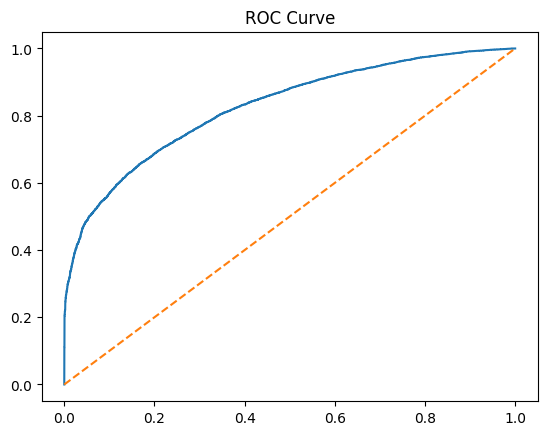

In [37]:
acc = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
roc = roc_auc_score(y_test, probs)

print("Accuracy:", acc)
print("ROC AUC:", roc)
print("Confusion Matrix:\n", cm)

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_res, y_res, cv=cv, scoring="accuracy")

print("CV Scores:", scores)
print("Mean CV:", scores.mean())

CV Scores: [0.74493055 0.73844553 0.74451919 0.74122202 0.7446098 ]
Mean CV: 0.74274541853468


In [ ]:
#print("\nStep 4.1: Chi-Square Test...")

#categorical_cols = ["Emp_Level", "Demographic_Category", "Housing_Category",
#                    "Region_Level", "Existing_Liabilities"]

#chi2_results = {}

#for col in categorical_cols:
#    contingency_table = pd.crosstab(X[col], y)
#    chi2, p, dof, expected = chi2_contingency(contingency_table)
#    chi2_results[col] = p
#    print(f"{col} p-value: {p}")

# Drop features with p > 0.05
#low_importance_cat = [col for col, p in chi2_results.items() if p > 0.05]

#print("Low importance categorical features:", low_importance_cat)

p-value < 0.05 for Existing_Liabilities,  Emp_Level , Housing_Category, Demographic_Category, Product_Cate  . So Important feature


Existing_Liabilities has High Chi2 score means Strong relationship

Higher F-score → More discriminative
p-value < 0.05 → Significant

 Feature      F-Score        p-value
4         LTV_Perc  2674.408262   0.000000e+00
3         Loan_Amt   905.838163  3.427642e-198
1       Birth Year   108.826238   1.821057e-25
0  Education Level    45.602399   1.455846e-11
2              Zip     0.442927   5.057143e-01
5          Net_Sal     0.375082   5.402482e-01

                   Feature  Importance
3                 LTV_Perc    0.212868
17  Existing_Liabilities_Y    0.091562
16  Existing_Liabilities_N    0.081739
1             Product_Cate    0.075010
9             Emp_Level_SA    0.049598
12  Demographic_Category_M    0.046180
2                 Loan_Amt    0.046126
5                      Age    0.045223
6             Emp_Level_AG    0.045178
15   Housing_Category_Rent    0.040881


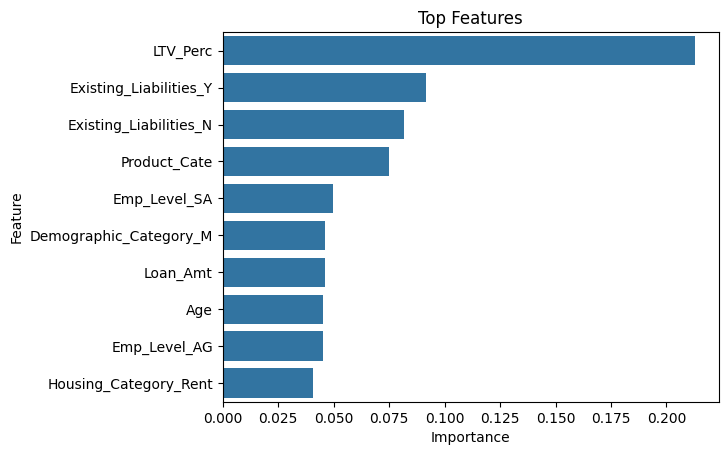


 thus:
- Top 2 features are strong predictors
- Bottom are Weak predictors


In [40]:
ohe = model.named_steps["prep"].named_transformers_["cat"]["encoder"]
cat_names = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(cat_names)

importances = model.named_steps["clf"].feature_importances_

feat_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

sns.barplot(data=feat_df.head(10), x="Importance", y="Feature")
plt.title("Top Features")
plt.show()

print("\n thus:")
print("- Top 2 features are strong predictors")
print("- Bottom are Weak predictors")

In [41]:
sample_df = X.sample(5, random_state=42)

assert list(sample_df.columns) == list(X.columns)

print("Schema validation passed")

Schema validation passed


In [45]:
print("\n Verfication - Sample Prediction\n")

# --- Sample input ---
sample_input = pd.DataFrame([{
    "Education Level": 0,
    "Emp_Level": "SE",
    "Birth Year": 1969,
    "Zip": 123020,
    "Demographic_Category": "M",
    "Product_Cate": 2,
    "Loan_Amt": 57971,
    "LTV_Perc": 99.23,
    "Housing_Category": "Owner",
    "Net_Sal": 30000,
    "Region_Level": 7,
    "Existing_Liabilities": "Y"
}])

print("Input:\n", sample_input)


# --- Apply SAME feature engineering ---
current_year = datetime.datetime.now().year
sample_input["Age"] = current_year - sample_input["Birth Year"]

# Drop same columns
sample_input = sample_input.drop(columns=["Birth Year", "Region_Level", "Zip"])

print("\n After Feature Engineering:\n", sample_input)


# --- Merge rare categories using SAME logic ---
def merge_rare_inference(series, train_series, threshold=0.02):
    freq = train_series.value_counts(normalize=True)
    rare = freq[freq < threshold].index
    return series.apply(lambda x: x if x in freq.index and x not in rare else "Other")

for col in categorical_cols:
    sample_input[col] = merge_rare_inference(sample_input[col], X[col])


# --- Ensure SAME column order ---
sample_input = sample_input[X.columns]

print("\n Final Input (Aligned with Training Columns):")
print(sample_input.columns.tolist())


# --- Prediction ---
probs = model.predict_proba(sample_input)[:, 1]

threshold = 0.65
prediction = (probs >= threshold).astype(int)

print("\n Prediction Results:")
print("Probability of Approval:", probs[0])
# print("Final Decision (1=Approved, 0=Rejected):", prediction[0])



 Verfication - Sample Prediction

Input:
    Education Level Emp_Level  Birth Year     Zip Demographic_Category  \
0                0        SE        1969  123020                    M   

   Product_Cate  Loan_Amt  LTV_Perc Housing_Category  Net_Sal  Region_Level  \
0             2     57971     99.23            Owner    30000             7   

  Existing_Liabilities  
0                    Y  

 After Feature Engineering:
    Education Level Emp_Level Demographic_Category  Product_Cate  Loan_Amt  \
0                0        SE                    M             2     57971   

   LTV_Perc Housing_Category  Net_Sal Existing_Liabilities  Age  
0     99.23            Owner    30000                    Y   57  

 Final Input (Aligned with Training Columns):
['Education Level', 'Emp_Level', 'Demographic_Category', 'Product_Cate', 'Loan_Amt', 'LTV_Perc', 'Housing_Category', 'Net_Sal', 'Existing_Liabilities', 'Age']

 Prediction Results:
Probability of Approval: 0.40357238
Final Decision (1=Ap

In [46]:
import joblib


In [48]:
import joblib

# Extract the imputer and encoder from the preprocessor pipeline
imputer = model.named_steps['prep'].named_transformers_['num'].named_steps['imputer']
encoders = model.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']

joblib.dump(model, "A5_ARS_loan_model.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(imputer, "imputer.pkl")

print("* Model and preprocessing components saved - pkl files")

* Model and preprocessing components saved - pkl files
